In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


In [ ]:
# Set layer widths

widthD = 10
widthF = 1
widthP = 30

# Set up lattice
X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

# Set up Hamiltonian parameters
t = 1
T = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

# U, V and V' must be of dimensions (lattice.X,) or None
U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 6 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 2 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

In [ ]:
# Set up Hamiltonian with 
# initial guesses for the order parameters

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.65, 0.65, -0.65, -0.65],
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
                hx=h)

In [ ]:
fixed_sites = (V_prime == 0)  # Boolean array of sites where the order parameters are fixed to their initial values

# The symmetries of the order parameters that are fixed to their initial values at the fixed sites.
fixed_syms = ["F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin"]

# Perform self-consistency iterations
partial_sc(H, temperature=T,
           fixed_sites=fixed_sites,
           fixed_syms=fixed_syms,
           atol=1e-3, rtol=1e-1, maxiter=100, 
           verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.0024451313628739177
Relative error: 2445131362.873918
Average old: 0j
Average: (0.00019590643330661195+0j)
F_xplus:
Absolute error: 0.021295412200789992
Relative error: 21295412200.789993
Average old: (0.1625+0j)
Average: (0.16414656244031153+0j)
F_xmin:
Absolute error: 0.016632060372054395
Relative error: 16632060372.054394
Average old: (0.14625+0j)
Average: (0.14487349303572436+0j)
F_yplus:
Absolute error: 0.007468465805535278
Relative error: 7468465805.535276
Average old: (-0.15853658536585366+0j)
Average: (-0.15894424453586536-0.00010782938748666977j)
F_ymin:
Absolute error: 0.007468465805535278
Relative error: 7468465805.535276
Average old: (-0.15853658536585366+0j)
Average: (-0.15894424453586536+0.00010782938748666977j)
Fuu_xplus:
Absolute error: 0.05793780079989651
Relative error: 56205632552.34584
Average old: (0.007250000000000001+0j)
Average: (0.010414079058895307+0j)
Fuu_xmin:
Absolute error: 0.05531980197209238
Relative error: 52587814630.042915
Averag

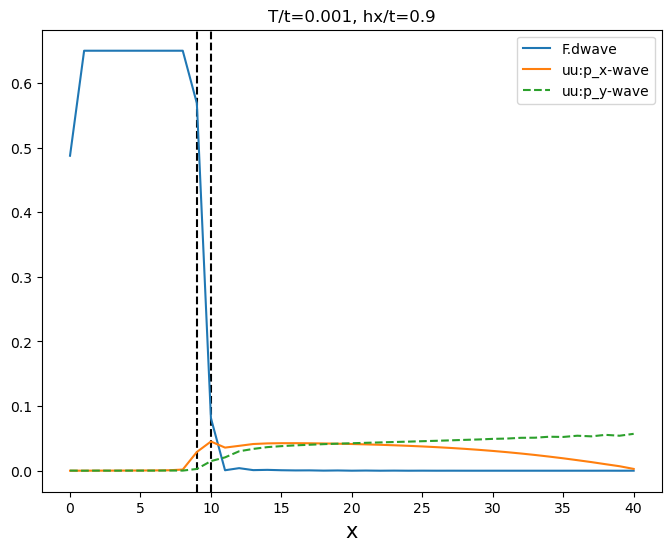

In [5]:
x = np.arange(0, widthD + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(widthD-1, color='black', linestyle='--')
axs.axvline(widthD+widthF-1, color='black', linestyle='--')

axs.plot(x, np.abs(F.dwave), label="F.dwave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")

axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [6]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
